# Logistische Regression für den AI4I-Datensatz

## Ziel
In diesem Notebook wird eine logistische Regression in Matrix-Schreibweise mit NumPy implementiert, um den Fehlertyp TWF vorherzusagen.

## Anforderungen
- Manuelle Implementierung mit NumPy
- Gewichtete Kostenfunktion
- Confusion Matrix
- F1-Score
- Plot der Entscheidungsgrenze

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression

In [34]:
df = pd.read_csv("ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
TARGET = 'TWF'
FEATURES = ['Tool wear [min]', 'Rotational speed [rpm]'] #gewählt, da Verschleiß und drehzahl Stark auf das Werkzeug einwirken

In [36]:
X = df[FEATURES].values # einlesen der Features als numpy array
y = df[TARGET].values.reshape(-1, 1) # einlesen des Ziels als numpy array

print("Anzahl Datenpunkte:", X.shape[0])
print("Anzahl Features:", X.shape[1])
print("Positive Fälle:", np.sum(y))

Anzahl Datenpunkte: 10000
Anzahl Features: 2
Positive Fälle: 46


In [37]:
# 7. Train-Test-Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, #80% Trainingsdaten, 20% Testdaten
    random_state=42,
    stratify=y # Stratify=y um Klassenverhältnis in Trainings- und Testdaten zu erhalten
)

print("Trainingsdaten:", X_train.shape)
print("Testdaten:", X_test.shape)

Trainingsdaten: (8000, 2)
Testdaten: (2000, 2)


In [38]:
# 8. Standardisierung

# Mittelwerte und Standardabweichungen der Trainingsdaten
means = X_train.mean(axis=0)
stds = X_train.std(axis=0)
# Division durch 0 verhindern
stds[stds == 0] = 1.0

# Standardisieren
X_train = (X_train - means) / stds
X_test = (X_test - means) / stds

In [39]:
# 9. Bias-Term hinzufügen
# Erste Spalte aus Einsen für den Achsenabschnitt beta_0.

X_train = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

In [40]:
# 10. Sigmoid-Funktion

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [41]:
# 11. Gewichtete Kostenfunktion
# Da positive Fälle (Ausfälle) selten sind, wird die positive Klasse stärker gewichtet.

n_pos = np.sum(y_train == 1)
n_neg = np.sum(y_train == 0)

# Gewicht für positive Klasse
w_pos = n_neg / n_pos
# Gewicht für negative Klasse
w_neg = 1.0

print(f"Positive Fälle im Training: {n_pos}")
print(f"Negative Fälle im Training: {n_neg}")
print(f"Gewicht positive Klasse: {w_pos:.2f}")


def weighted_cost(X, y, beta):
    m = len(y)

    y_hat = sigmoid(X @ beta)
    eps = 1e-15
    y_hat = np.clip(y_hat, eps, 1 - eps)

    # Gewichte abhängig von der Klasse
    weights = np.where(y == 1, w_pos, w_neg)

    # Gewichteter Log-Loss
    loss = -weights * (
        y * np.log(y_hat) +
        (1 - y) * np.log(1 - y_hat)
    )

    return np.mean(loss)

Positive Fälle im Training: 37
Negative Fälle im Training: 7963
Gewicht positive Klasse: 215.22


In [42]:
# 12. Training mittels Gradientenabstieg

def fit_logistic_regression(X, y,alpha=0.01,iterations=5000):
    
    m, n = X.shape

    # Parametervektor initialisieren
    beta = np.zeros((n, 1))

    # Kostenhistorie speichern
    cost_history = []

    for i in range(iterations):
        # Vorhersagewahrscheinlichkeiten
        y_hat = sigmoid(X @ beta)

        # Gewichte je Datenpunkt
        weights = np.where(y == 1, w_pos, w_neg)

        # Gewichteter Fehler
        error = (y_hat - y) * weights

        # Gradient
        gradient = (X.T @ error) / m

        # Parameterupdate
        beta = beta - alpha * gradient

        # Kosten speichern
        cost = weighted_cost(X, y, beta)
        cost_history.append(cost)

        # Fortschritt alle 500 Iterationen
        if i % 500 == 0:
            print(f"Iteration {i:5d} | Kosten = {cost:.6f}")

    return beta, cost_history

In [43]:
# 13. Modell trainieren

beta, cost_history = fit_logistic_regression(
    X_train,
    y_train,
    alpha=0.01,
    iterations=5000
)

print("\nGelernte Parameter:")
print(beta)

Iteration     0 | Kosten = 1.372373
Iteration   500 | Kosten = 0.743691
Iteration  1000 | Kosten = 0.636950
Iteration  1500 | Kosten = 0.583621
Iteration  2000 | Kosten = 0.549986
Iteration  2500 | Kosten = 0.526144
Iteration  3000 | Kosten = 0.508027
Iteration  3500 | Kosten = 0.493611
Iteration  4000 | Kosten = 0.481760
Iteration  4500 | Kosten = 0.471778

Gelernte Parameter:
[[-3.50719813]
 [ 3.10140542]
 [ 0.12361156]]


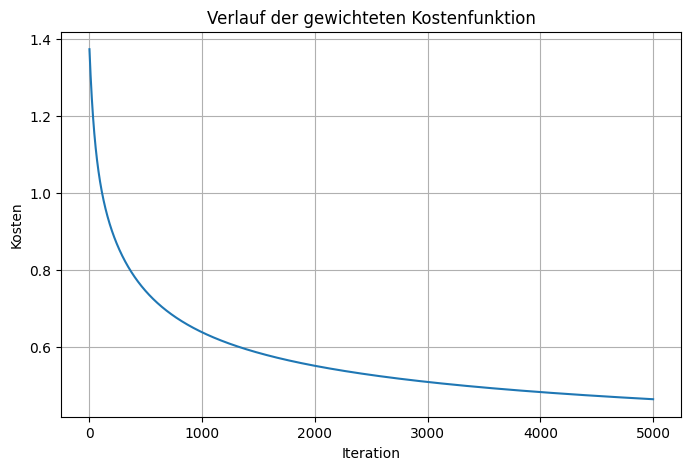

In [44]:
# 14. Kostenverlauf plotten

plt.figure(figsize=(8, 5))
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Kosten")
plt.title("Verlauf der gewichteten Kostenfunktion")
plt.grid(True)
plt.show()

In [45]:
# 15. Vorhersagefunktion

def predict(X, beta, threshold=0.7): #Entscheidungsgrenze bei 0.7
    probabilities = sigmoid(X @ beta)
    return (probabilities >= threshold).astype(int)

# 16. Vorhersagen auf Testdaten
y_pred = predict(X_test, beta)

In [46]:
# 17. Confusion Matrix und F1-Score

# Umwandeln von y-test und y_pred in 1D-Arrays für die Metriken
y_test1D = y_test.ravel()
y_pred1D = y_pred.ravel()

# Berechnen von TP, TN, FP und FN
TP = np.sum((y_test1D == 1) & (y_pred1D == 1))
TN = np.sum((y_test1D == 0) & (y_pred1D == 0))
FP = np.sum((y_test1D == 0) & (y_pred1D == 1))
FN = np.sum((y_test1D == 1) & (y_pred1D == 0))

# Confusion Matrix erstellen
Confusion_Matrix = np.array([[TN, FP], [FN, TP]])
print("Confusion Matrix:")
print(Confusion_Matrix)

# F1-Score berechnen
#Precision und Recall berechnen
precision_manuell = TP / (TP+FP)
recall_manuell = TP / (TP+FN)
f1_score_manuell = 2 * (precision_manuell * recall_manuell) / (precision_manuell + recall_manuell)

print(f"Precision: {precision_manuell:.5f}")
print(f"Recall: {recall_manuell:.5f}")
print(f"F1-Score: {f1_score_manuell:.5f}")


Confusion Matrix:
[[1802  189]
 [   0    9]]
Precision: 0.04545
Recall: 1.00000
F1-Score: 0.08696


- Confusion Matrix:
    - OL: True Negativ    OR: False Positive
    - UL: False Negariv   UR: Treu Positive

    - Recall = TP/(TP+FN) = 1.0 -> alle tatsächlichen Ausfälle gefunden 
    - Precision = TP/(TP+FP) = 0,04545 -> nur 4,45% der erkannten ausfälle sind tatsächlich Ausfälle, also viele "Fehlalarme" (Fehler 1. Art)
    - -> Aufteilung so gweählt um mögliche größere folgekosten zu verhindern wenn mit einem nicht erkannten schaden weiter gefahren wird
    
- F1-Score
    - F1 = 0,087 ist so niedrig weil alle Ausfälle zu erkennen priorisiert wird und somit eine schlechte Prazisioin mit sich zieht

In [47]:
# 18. Vergleich mit scikit-learn

sk_model = LogisticRegression(
    class_weight='balanced',
    max_iter=10000
)

# sklearn benötigt Daten ohne reshape-Probleme
sk_model.fit(X_train[:, 1:], y_train.ravel())

# Vorhersagen mit scikit-learn Modell
y_pred_sk = sk_model.predict(X_test[:, 1:])

# Berechnung der Metriken mit scikit-learn
confusion_matrix_sk = confusion_matrix(y_test, y_pred_sk)
precision_sk = precision_score(y_test.ravel(), y_pred_sk)
recall_sk = recall_score(y_test.ravel(), y_pred_sk)
f1_sk = f1_score(y_test, y_pred_sk)

print("Confusion Matrix (scikit-learn):")
print(confusion_matrix_sk)
print(f"Precision (scikit-learn): {precision_sk:.5f}")
print(f"Recall (scikit-learn): {recall_sk:.5f}")
print(f"F1-Score (scikit-learn): {f1_sk:.5f}")


Confusion Matrix (scikit-learn):
[[1785  206]
 [   0    9]]
Precision (scikit-learn): 0.04186
Recall (scikit-learn): 1.00000
F1-Score (scikit-learn): 0.08036


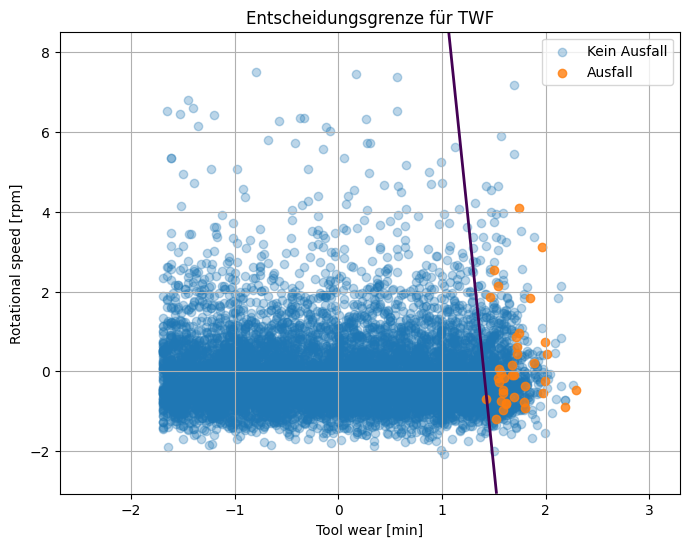

In [48]:
# 19. Entscheidungsgrenze plotten

# Daten ohne Bias-Term verwenden
X_plot = X_train[:, 1:]

plt.figure(figsize=(8, 6))

# Punkte darstellen
plt.scatter(
    X_plot[y_train.ravel() == 0, 0], # Tool wear
    X_plot[y_train.ravel() == 0, 1], # Rotational speed
    alpha=0.3, 
    label='Kein Ausfall'
)

plt.scatter(
    X_plot[y_train.ravel() == 1, 0],
    X_plot[y_train.ravel() == 1, 1],
    alpha=0.8,
    label='Ausfall'
)

# Gitter für Entscheidungsgrenze
x1_min, x1_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
x2_min, x2_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1

xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 200),
    np.linspace(x2_min, x2_max, 200)
)

grid = np.c_[xx1.ravel(), xx2.ravel()] # Gitterpunkte in 2D-Array umwandeln

# Bias-Term hinzufügen
grid_bias = np.hstack((np.ones((grid.shape[0], 1)), grid))

# Wahrscheinlichkeiten berechnen
Z = sigmoid(grid_bias @ beta) # Wahrscheinlichkeiten für jeden Gitterpunkt berechnen
Z = Z.reshape(xx1.shape) # Wahrscheinlichkeiten zurück in die Form des Gitters bringen

# Entscheidungsgrenze bei p = 0.7
plt.contour(xx1, xx2, Z, levels=[0.7], linewidths=2)

plt.xlabel('Tool wear [min]')
plt.ylabel('Rotational speed [rpm]')
plt.title(f"Entscheidungsgrenze für TWF")
plt.legend()
plt.grid(True)
plt.show()